In [1]:
from sentence_transformers import SentenceTransformer

from papers_data import papers

/Users/sbamwite/Desktop/rags/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/sbamwite/Desktop/rags/env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 12 paper abstracts
Topics covered: Machine Learning, Data Engineering, and Data Visualization


In [2]:
### Load the pre-trained embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')
# fast and efficient for learning purposes, perfect for understanding the core concepts

In [3]:
### Extract just the abstracts for embedding
abstracts = [paper['abstract'] for paper in papers]


In [4]:
### Generate embeddings for all abstracts
embeddings = model.encode(abstracts)

In [5]:
### examine what we've created
print(f"Shape of embeddings: {embeddings.shape}")
print(f"Each abstract is represented by a vector of {embeddings.shape[1]} numbers")
print(f"\nFirst few values of the first embedding:")
print(embeddings[0][:10])

Shape of embeddings: (12, 384)
Each abstract is represented by a vector of 384 numbers

First few values of the first embedding:
[-0.06071806 -0.13064866  0.00328696 -0.04209435 -0.03220841  0.02034249
  0.00421565 -0.01300789 -0.10266113 -0.04565622]


In [ ]:
"""
Each embedding is a 384-dimensional vector, represented as a NumPy array of
floating-point numbers.

The numbers encode meaningful information about the semantic content
of each abstract. They represent the abstract's position in a
high-dimensional vector space learned by the model during training.
When we want to find similar documents, we measure the cosine similarity
between their embedding vectors. Cosine similarity looks at the angle between
vectors.
Vectors pointing in similar directions (representing similar meanings)
have high cosine similarity, even if their magnitudes differ.
In a later lesson, we'll compute vector similarity using cosine, Euclidean,
and dot-product methods to compare different approaches.

you cannot directly compare embeddings from different models because they
use different vector spaces.
"""

In [8]:
### Let's look at one paper and its embedding
print("Paper title:", papers[0]['title'])
print("\nAbstract:", papers[0]['abstract'][:100] + "...")
print("\nEmbedding shape:", embeddings[0].shape)
print("Embedding type:", type(embeddings[0]))

Paper title: Building Your First Neural Network with PyTorch

Abstract: Learn how to construct and train a neural network from scratch using PyTorch. This paper covers the ...

Embedding shape: (384,)
Embedding type: <class 'numpy.ndarray'>


In [9]:
# Principal Component Analysis
"""
technique that can be used to find the two most important dimensions
i.e. the ones that capture the most variation in the data.

like taking a 3D obj and finding the best angle to photograph it in 2D
while preserving as much information as possible.

this is done because we have a hard enough time imagining 4D, let alone 384D.

example;
if one wants to visualize embeddings of 50 documents in 2D.
The original embeddings have 768 dimensions. 
PCA identifies the principal components (directions) in the original
high-dimensional space that explain the most variance,
allowing us to project the data onto these 2 most informative dimensions.
"""
from sklearn.decomposition import PCA

In [10]:
### Reduce embeddings from 384 dimensions to 2 dimensions
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

In [11]:
print(f"Original embedding dimensions: {embeddings.shape[1]}")
print(f"Reduced embedding dimensions: {embeddings_2d.shape[1]}")
print(f"\nVariance explained by these 2 dimensions: {pca.explained_variance_ratio_.sum():.2%}")

Original embedding dimensions: 384
Reduced embedding dimensions: 2

Variance explained by these 2 dimensions: 41.20%


In [12]:
"""
here we see how the 12 papers are organized by topic.
it will help us understand the patterns we see in the embeddings
"""

### Print papers grouped by topic
print("=" * 80)
print("PAPER REFERENCE GUIDE")
print("=" * 80)

topics = [
    ("Machine Learning", list(range(0, 4))),
    ("Data Engineering/ETL", list(range(4, 8))),
    ("Data Visualization", list(range(8, 12)))
]

for topic_name, indices in topics:
    print(f"\n{topic_name}:")
    print("-" * 80)
    for idx in indices:
        print(f"  Paper {idx+1}: {papers[idx]['title']}")

PAPER REFERENCE GUIDE

Machine Learning:
--------------------------------------------------------------------------------
  Paper 1: Building Your First Neural Network with PyTorch
  Paper 2: Preventing Overfitting: Regularization Techniques Explained
  Paper 3: Hyperparameter Tuning with Grid Search and Random Search
  Paper 4: Transfer Learning: Using Pre-trained Models for Image Classification

Data Engineering/ETL:
--------------------------------------------------------------------------------
  Paper 5: Handling Missing Data: Strategies and Best Practices
  Paper 6: Data Validation Techniques for ETL Pipelines
  Paper 7: Cleaning Messy CSV Files: A Practical Guide
  Paper 8: Building Scalable ETL Workflows with Apache Airflow

Data Visualization:
--------------------------------------------------------------------------------
  Paper 9: Creating Interactive Dashboards with Plotly Dash
  Paper 10: Matplotlib Best Practices: Making Publication-Quality Plots
  Paper 11: Data Storyte

In [13]:
import matplotlib.pyplot as plt
import numpy as np


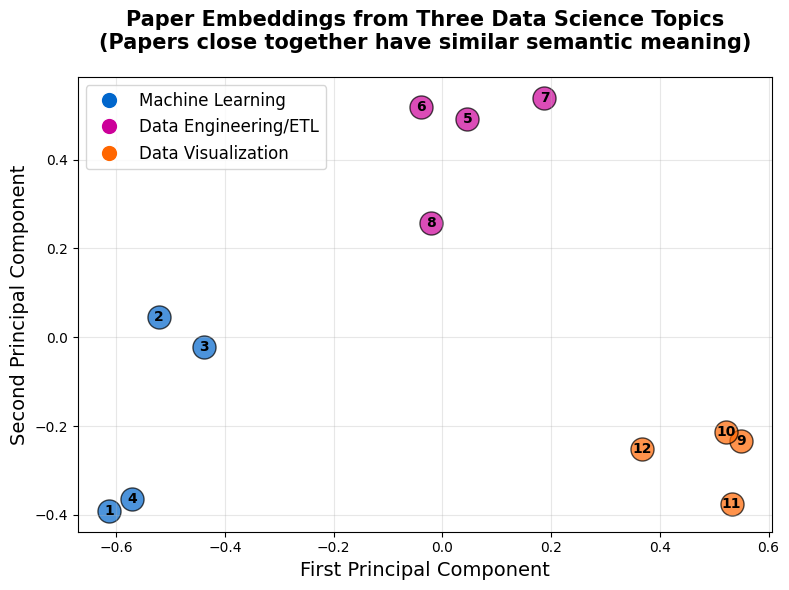

In [14]:

### Create the visualization
plt.figure(figsize=(8, 6))

### Define colors for different topics
colors = ['#0066CC', '#CC0099', '#FF6600']
categories = ['Machine Learning', 'Data Engineering/ETL', 'Data Visualization']

### Create color mapping for each paper
color_map = []
for i in range(12):
    if i < 4:
        color_map.append(colors[0])  # Machine Learning
    elif i < 8:
        color_map.append(colors[1])  # Data Engineering
    else:
        color_map.append(colors[2])  # Data Visualization

### Plot each paper
for i, (x, y) in enumerate(embeddings_2d):
    plt.scatter(x, y, c=color_map[i], s=275, alpha=0.7, edgecolors='black', linewidth=1)
    # Add paper numbers as labels
    plt.annotate(str(i+1), (x, y), fontsize=10, fontweight='bold',
                ha='center', va='center')

plt.xlabel('First Principal Component', fontsize=14)
plt.ylabel('Second Principal Component', fontsize=14)
plt.title('Paper Embeddings from Three Data Science Topics\n(Papers close together have similar semantic meaning)',
          fontsize=15, fontweight='bold', pad=20)

### Add a legend showing which colors represent which topics
legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=colors[i], markersize=12,
                              label=categories[i]) for i in range(len(categories))]
plt.legend(handles=legend_elements, loc='best', fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
"""
**How the Model Learned to Understand Meaning**
The all-MiniLM-L6-v2 embedding model was trained on millions of text pairs -- __are these synonyms?__,
learning which words tend to appear together. When it sees a lesson full of words like "layers,"
"training," and "optimization," it produces an embedding vector that's mathematically similar to
other texts with that same vocabulary pattern. The clustering emerges naturally from those
learned associations.
"""

"""
no, not synonyms;

The text pairs used to train the all-MiniLM-L6-v2 model are not necessarily synonyms.
Instead, they're likely pairs of texts that are semantically similar or related in some way.

The model is trained using a technique called contrastive learning or sentence embedding training,
where it's shown many pairs of texts and learns to:

- Bring closer together (in the vector space) texts that are semantically similar or related.
- Push apart texts that are dissimilar.

These text pairs can be:

- Paraphrases
- Texts with similar meanings
- Texts that are related in context

The goal is for the model to learn a representation that captures the underlying semantic
meaning of the text, not just to identify exact synonyms.

For example, the model might be trained on pairs like:

"The cat sat on the mat." and "A feline rested on the carpet."
"The new policy will be implemented next quarter." and "The company will roll out the new policy in the next three months."
These pairs are not necessarily synonyms, but they convey similar meanings or are related in context. The model learns to represent these texts in a way that reflects their semantic similarity.
"""

'\nno, no synonyms;\n'